In [3]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from PIL import Image
from tqdm import tqdm
import multiprocessing

# 1. Global Configurations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 5
NUM_CLASSES = 9
NUM_WORKERS = min(4, multiprocessing.cpu_count())

# Use the local path assuming you unzipped it in Colab /content/
data_dir = '/content/drive/MyDrive/datasets/Skin cancer ISIC The International Skin Imaging Collaboration'
train_dir = os.path.join(data_dir, 'Train')
test_dir = os.path.join(data_dir, 'Test')

# 2. Custom Filter Class
class ApplySpatialFilter:
    def __init__(self, filter_type='none'):
        self.filter_type = filter_type

    def __call__(self, img):
        if self.filter_type == 'none': return img

        img_np = np.array(img)
        img_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        if self.filter_type == 'average':
            img_cv = cv2.blur(img_cv, (5, 5))
        elif self.filter_type == 'gaussian':
            img_cv = cv2.GaussianBlur(img_cv, (5, 5), 0)
        elif self.filter_type == 'median':
            img_cv = cv2.medianBlur(img_cv, 5)
        elif self.filter_type == 'sharpening':
            kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
            img_cv = cv2.filter2D(img_cv, -1, kernel)
        elif self.filter_type == 'sobel':
            sobelx = cv2.Sobel(img_cv, cv2.CV_64F, 1, 0, ksize=3)
            sobely = cv2.Sobel(img_cv, cv2.CV_64F, 0, 1, ksize=3)
            img_cv = cv2.convertScaleAbs(np.sqrt(sobelx**2 + sobely**2))

        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        return Image.fromarray(img_rgb)

# 3. Master Experiment Function
def run_filter_experiment(filter_name):
    models_to_test = {
        'EfficientNet-B0': models.efficientnet_b0,
        'ResNet101': models.resnet101,
        'ResNet50': models.resnet50
    }

    print(f"\n{'='*60}\nSTARTING EXPERIMENTS FOR FILTER: {filter_name.upper()}\n{'='*60}")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        ApplySpatialFilter(filter_type=filter_name),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_data = datasets.ImageFolder(train_dir, transform=transform)
    test_data = datasets.ImageFolder(test_dir, transform=transform)

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                              pin_memory=True, num_workers=NUM_WORKERS, persistent_workers=True)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                             pin_memory=True, num_workers=NUM_WORKERS, persistent_workers=True)

    for model_name, model_func in models_to_test.items():
        print(f"\n--- Training {model_name} ---")
        model = model_func(weights='IMAGENET1K_V1')

        if 'resnet' in model_name.lower():
            model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
        elif 'efficientnet' in model_name.lower():
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        scaler = torch.amp.GradScaler('cuda')

        for epoch in range(EPOCHS):
            model.train()
            train_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

            for inputs, labels in train_iterator:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                probs = F.softmax(outputs, dim=1).cpu().numpy()
                preds = torch.max(outputs, 1)[1].cpu().numpy()

                all_labels.extend(labels.numpy())
                all_preds.extend(preds)
                all_probs.extend(probs)

        acc = accuracy_score(all_labels, all_preds) * 100
        prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

        try:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') * 100
        except ValueError:
            auc = 0.0

        print(f"[RESULTS] {model_name} + {filter_name.capitalize()}")
        print(f"Accuracy: {acc:.2f}% | Precision (Macro): {prec_macro*100:.2f}% | Recall (Macro): {rec_macro*100:.2f}% | F1-Score: {f1_macro*100:.2f}% | AUC: {auc:.2f}%")

        del model, optimizer, criterion, scaler
        torch.cuda.empty_cache()

In [4]:
# 1. Baseline Experiment: Original unmodified images
run_filter_experiment('none')


STARTING EXPERIMENTS FOR FILTER: NONE

--- Training EfficientNet-B0 ---


[RESULTS] EfficientNet-B0 + None
Accuracy: 59.32% | Precision (Macro): 58.57% | Recall (Macro): 57.64% | F1-Score: 54.47% | AUC: 0.00%

--- Training ResNet101 ---
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 170MB/s]


[RESULTS] ResNet101 + None
Accuracy: 53.39% | Precision (Macro): 62.16% | Recall (Macro): 52.78% | F1-Score: 51.55% | AUC: 0.00%

--- Training ResNet50 ---
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


[RESULTS] ResNet50 + None
Accuracy: 52.54% | Precision (Macro): 54.08% | Recall (Macro): 52.08% | F1-Score: 49.60% | AUC: 0.00%


In [5]:
# 2. Average (Mean) Smoothing Filter
run_filter_experiment('average')


STARTING EXPERIMENTS FOR FILTER: AVERAGE

--- Training EfficientNet-B0 ---


[RESULTS] EfficientNet-B0 + Average
Accuracy: 55.93% | Precision (Macro): 57.95% | Recall (Macro): 54.86% | F1-Score: 51.77% | AUC: 89.32%

--- Training ResNet101 ---


[RESULTS] ResNet101 + Average
Accuracy: 43.22% | Precision (Macro): 51.41% | Recall (Macro): 44.44% | F1-Score: 40.84% | AUC: 0.00%

--- Training ResNet50 ---


[RESULTS] ResNet50 + Average
Accuracy: 55.93% | Precision (Macro): 60.12% | Recall (Macro): 54.86% | F1-Score: 52.22% | AUC: 0.00%


In [6]:
# 3. Gaussian Blurring Filter
run_filter_experiment('gaussian')


STARTING EXPERIMENTS FOR FILTER: GAUSSIAN

--- Training EfficientNet-B0 ---


[RESULTS] EfficientNet-B0 + Gaussian
Accuracy: 58.47% | Precision (Macro): 58.25% | Recall (Macro): 56.94% | F1-Score: 54.10% | AUC: 0.00%

--- Training ResNet101 ---


[RESULTS] ResNet101 + Gaussian
Accuracy: 57.63% | Precision (Macro): 62.42% | Recall (Macro): 56.25% | F1-Score: 54.62% | AUC: 0.00%

--- Training ResNet50 ---


[RESULTS] ResNet50 + Gaussian
Accuracy: 51.69% | Precision (Macro): 49.91% | Recall (Macro): 51.39% | F1-Score: 46.52% | AUC: 0.00%


In [7]:
# 4. Median Smoothing Filter (Good for salt-and-pepper noise)
run_filter_experiment('median')


STARTING EXPERIMENTS FOR FILTER: MEDIAN

--- Training EfficientNet-B0 ---


[RESULTS] EfficientNet-B0 + Median
Accuracy: 56.78% | Precision (Macro): 60.34% | Recall (Macro): 55.56% | F1-Score: 54.31% | AUC: 0.00%

--- Training ResNet101 ---


[RESULTS] ResNet101 + Median
Accuracy: 51.69% | Precision (Macro): 62.02% | Recall (Macro): 51.39% | F1-Score: 48.18% | AUC: 0.00%

--- Training ResNet50 ---


[RESULTS] ResNet50 + Median
Accuracy: 50.85% | Precision (Macro): 50.44% | Recall (Macro): 50.69% | F1-Score: 46.47% | AUC: 0.00%


In [8]:
# 5. Spatial Sharpening Filter
run_filter_experiment('sharpening')


STARTING EXPERIMENTS FOR FILTER: SHARPENING

--- Training EfficientNet-B0 ---


[RESULTS] EfficientNet-B0 + Sharpening
Accuracy: 60.17% | Precision (Macro): 59.13% | Recall (Macro): 58.33% | F1-Score: 55.30% | AUC: 0.00%

--- Training ResNet101 ---


[RESULTS] ResNet101 + Sharpening
Accuracy: 57.63% | Precision (Macro): 72.21% | Recall (Macro): 59.26% | F1-Score: 58.12% | AUC: 0.00%

--- Training ResNet50 ---


[RESULTS] ResNet50 + Sharpening
Accuracy: 61.86% | Precision (Macro): 65.32% | Recall (Macro): 59.72% | F1-Score: 58.11% | AUC: 0.00%


In [9]:
# 6. Sobel Edge Detection (Removes color, extracts structural borders)
run_filter_experiment('sobel')


STARTING EXPERIMENTS FOR FILTER: SOBEL

--- Training EfficientNet-B0 ---


[RESULTS] EfficientNet-B0 + Sobel
Accuracy: 48.31% | Precision (Macro): 49.19% | Recall (Macro): 48.61% | F1-Score: 43.48% | AUC: 0.00%

--- Training ResNet101 ---


[RESULTS] ResNet101 + Sobel
Accuracy: 55.08% | Precision (Macro): 56.86% | Recall (Macro): 54.17% | F1-Score: 51.36% | AUC: 0.00%

--- Training ResNet50 ---


[RESULTS] ResNet50 + Sobel
Accuracy: 50.85% | Precision (Macro): 52.50% | Recall (Macro): 50.69% | F1-Score: 46.70% | AUC: 0.00%


**Visualization**

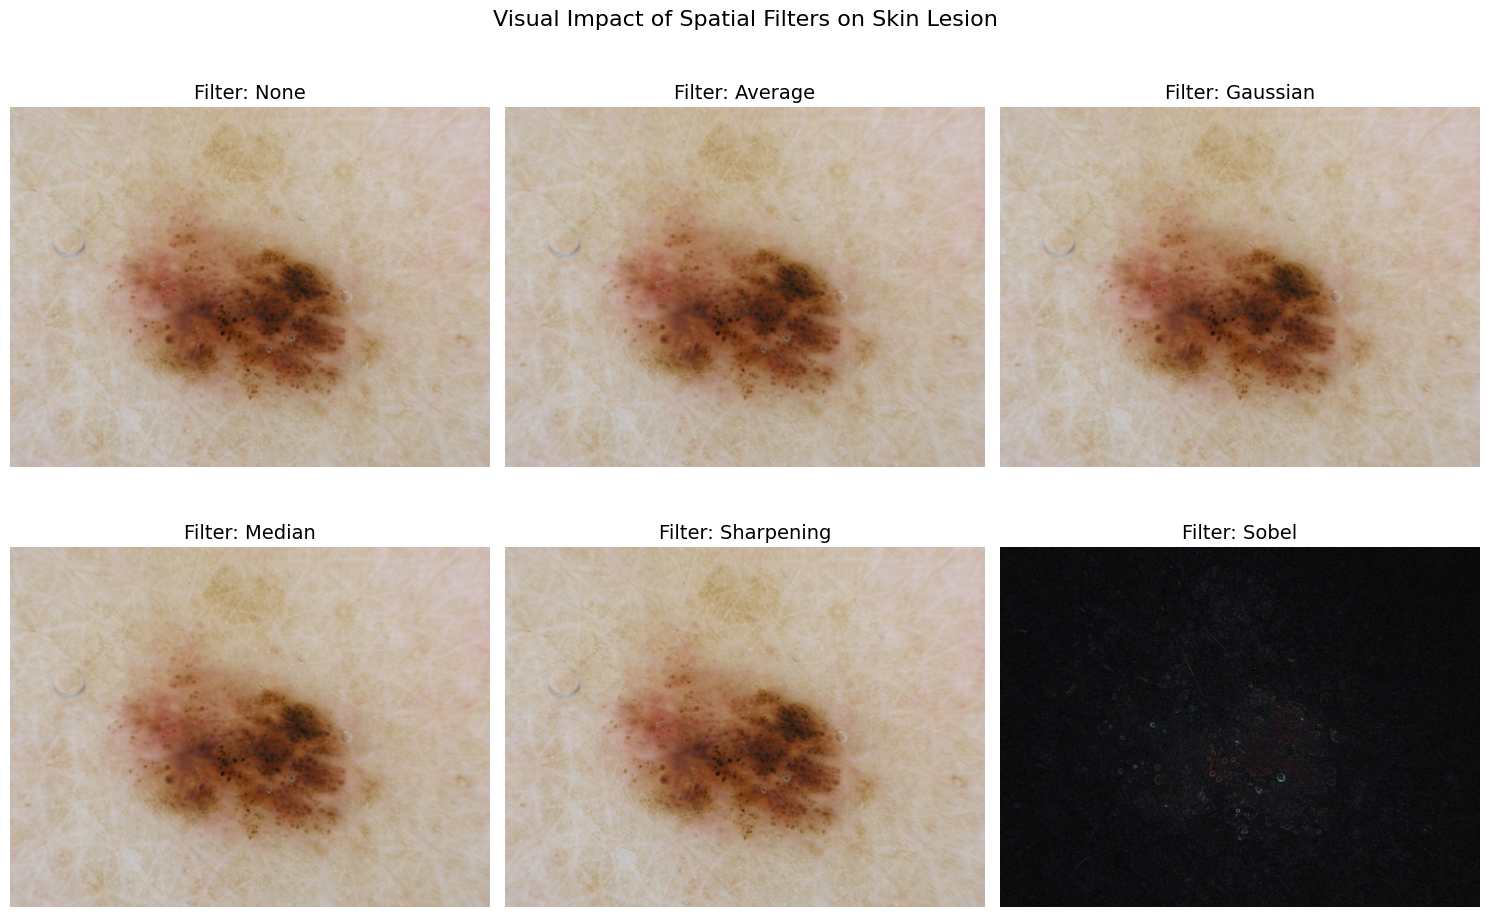

In [10]:
# ==========================================
# VISUALIZATION: Original vs Filtered Images
# ==========================================
import matplotlib.pyplot as plt

def visualize_filters(image_path):
    # Load original image
    raw_img = Image.open(image_path).convert('RGB')

    # Define all filters
    filters = ['none', 'average', 'gaussian', 'median', 'sharpening', 'sobel']

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("Visual Impact of Spatial Filters on Skin Lesion", fontsize=16)
    axes = axes.flatten()

    for ax, f_name in zip(axes, filters):
        # Apply the specific filter using your existing class
        filter_applier = ApplySpatialFilter(filter_type=f_name)
        filtered_img = filter_applier(raw_img)

        ax.imshow(filtered_img)
        ax.set_title(f"Filter: {f_name.capitalize()}", fontsize=14)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Grab a random image from the train directory for visualization
# Update this specific path to a valid .jpg inside one of your class folders
sample_img_path = os.path.join(train_dir, 'melanoma', os.listdir(os.path.join(train_dir, 'melanoma'))[0])
visualize_filters(sample_img_path)

**Comparative Analysis**

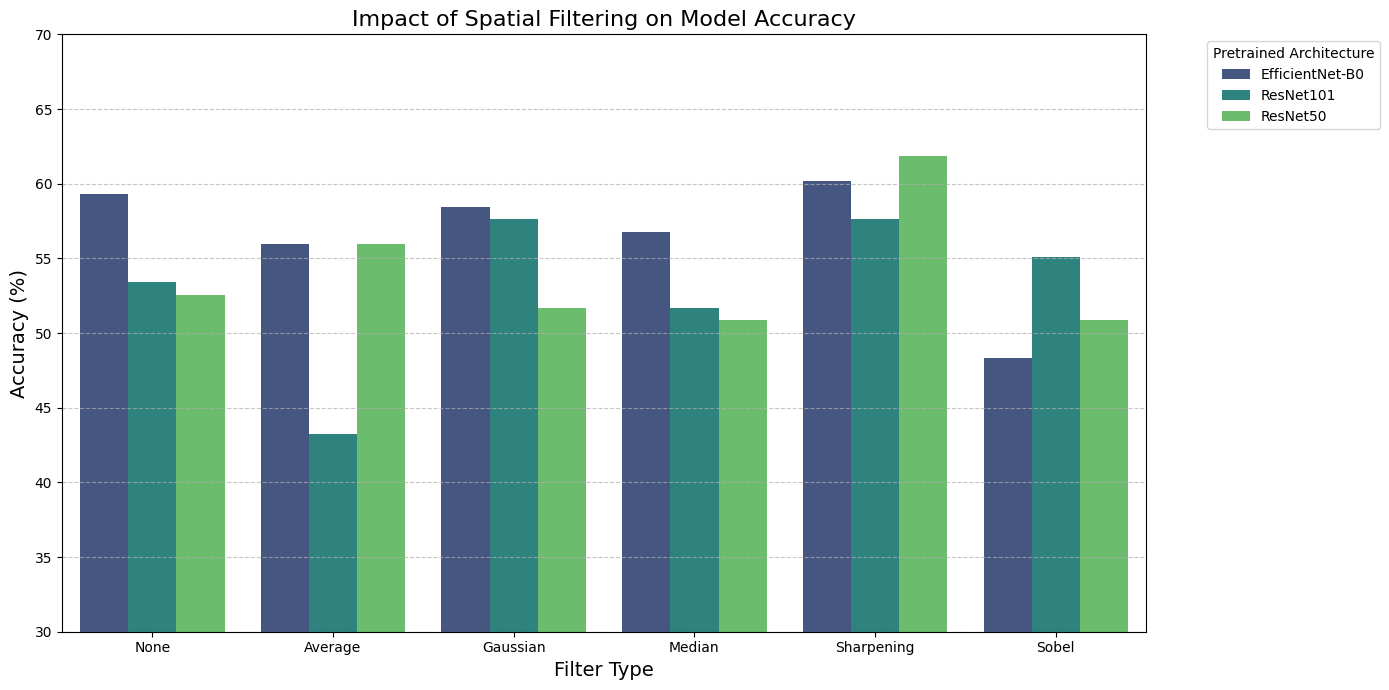

In [11]:
# ==========================================
# COMPARATIVE ANALYSIS
# ==========================================
import pandas as pd
import seaborn as sns

# Constructing a DataFrame from your console outputs
data = {
    'Model': ['EfficientNet-B0']*6 + ['ResNet101']*6 + ['ResNet50']*6,
    'Filter': ['None', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel'] * 3,
    'Accuracy': [
        # EfficientNet-B0
        59.32, 55.93, 58.47, 56.78, 60.17, 48.31,
        # ResNet101
        53.39, 43.22, 57.63, 51.69, 57.63, 55.08,
        # ResNet50
        52.54, 55.93, 51.69, 50.85, 61.86, 50.85
    ]
}

df = pd.DataFrame(data)

# Plotting the Comparative Analysis
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Filter', y='Accuracy', hue='Model', palette='viridis')

plt.title('Impact of Spatial Filtering on Model Accuracy', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.xlabel('Filter Type', fontsize=14)
plt.ylim(30, 70) # Adjusted for better visual scaling based on your results
plt.legend(title='Pretrained Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()